In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import (ttest_ind, f_oneway, chi2_contingency,
                         pearsonr, spearmanr)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 5)})


# DATA CLEANING

In [3]:
df = pd.read_csv("orbittel_raw.csv")
print(f"Raw shape: {df.shape}")

Raw shape: (12342, 16)


In [6]:
before = len(df)
df.drop_duplicates(subset=["customer_id", "bill_date"], keep="first", inplace=True)
print(f"Duplicates removed: {before - len(df)}")

Duplicates removed: 0


In [7]:
df["service_type"] = df["service_type"].str.strip().str.title()
df["city"]         = df["city"].str.strip().str.title()

In [8]:
df["signup_date"] = pd.to_datetime(df["signup_date"], dayfirst=True, errors="coerce")
df["bill_date"]   = pd.to_datetime(df["bill_date"],   dayfirst=True, errors="coerce")


In [9]:
df.loc[df["tenure_months"] < 0, "tenure_months"] = np.nan

In [10]:
df.loc[~df["customer_age"].between(18, 90), "customer_age"] = np.nan

In [14]:
for col in ["monthly_charges", "data_usage_gb"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    upper   = q3 + 3 * (q3 - q1)
    df.loc[df[col] > upper, col] = np.nan

In [16]:
df["tenure_months"]     = df["tenure_months"].fillna(df["tenure_months"].median())
df["contract_type"]     = df["contract_type"].fillna(df["contract_type"].mode()[0])
df["monthly_charges"]   = df["monthly_charges"].fillna(
    df.groupby("service_type")["monthly_charges"].transform("median"))
df["data_usage_gb"]     = df["data_usage_gb"].fillna(
    df.groupby("service_type")["data_usage_gb"].transform("median"))
df["support_calls"]     = df["support_calls"].fillna(df["support_calls"].median())
df["satisfaction_score"]= df["satisfaction_score"].fillna(df["satisfaction_score"].median())
df["customer_age"]      = df["customer_age"].fillna(df["customer_age"].median())

In [18]:
df["churn_bool"]   = df["churn"].str.strip().str.lower() == "yes"
df["bill_month"]   = df["bill_date"].dt.to_period("M")

In [19]:
tenure_bins   = [0, 3, 6, 12, 18, 24]
tenure_labels = ["0-3m", "4-6m", "7-12m", "13-18m", "19-24m"]
df["tenure_band"] = pd.cut(df["tenure_months"], bins=tenure_bins,
                            labels=tenure_labels, include_lowest=True)

In [21]:
age_bins   = [17, 25, 35, 45, 55, 65, 91]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["age_group"] = pd.cut(df["customer_age"], bins=age_bins, labels=age_labels)

In [23]:
print(f"Clean shape : {df.shape}")
print(f"Churn rate  : {df['churn_bool'].mean():.1%}")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print(f"Remaining missing:\n{missing}")

Clean shape : (11020, 20)
Churn rate  : 5.7%
Remaining missing:
signup_date    3017
dtype: int64


In [24]:
df.to_csv("orbittel_clean.csv", index=False)
print("Clean dataset saved -> orbittel_clean.csv\n")

Clean dataset saved -> orbittel_clean.csv



# EDA & BUSINESS

In [33]:
# Q1. Overall churn rate & month-over-month trend

In [34]:
overall_churn = df["churn_bool"].mean()
print(f"Q1 -- Overall Churn Rate: {overall_churn:.2%}")

monthly_churn = (df.groupby("bill_month")["churn_bool"]
                   .agg(["sum", "count"])
                   .rename(columns={"sum": "churned", "count": "total"}))
monthly_churn["churn_rate"] = monthly_churn["churned"] / monthly_churn["total"]
monthly_churn["ym_str"]     = monthly_churn.index.astype(str)


Q1 -- Overall Churn Rate: 5.70%


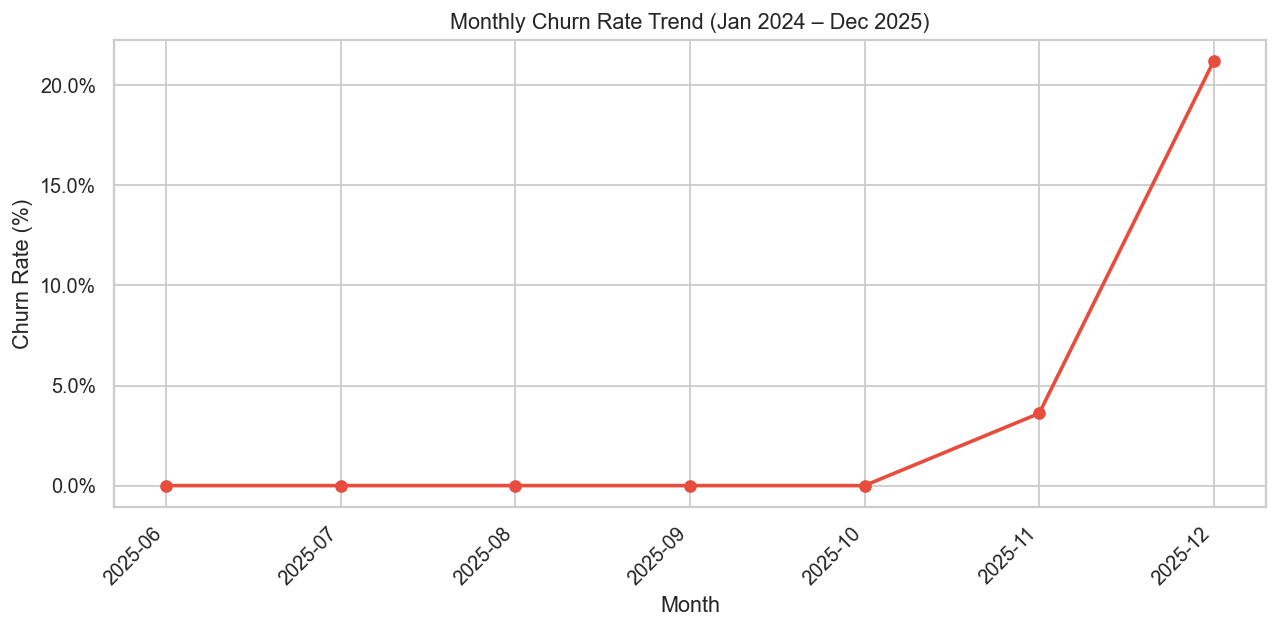

In [35]:
ig, ax = plt.subplots()
ax.plot(monthly_churn["ym_str"], monthly_churn["churn_rate"] * 100,
        marker="o", linewidth=2, color="#e74c3c")
ax.set_title("Monthly Churn Rate Trend (Jan 2024 – Dec 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Churn Rate (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("q1_churn_trend.png")
plt.show()

In [36]:
# Q2. Churn by service type & region

In [42]:
svc_churn = (df.groupby("service_type")["churn_bool"].mean()
               .sort_values(ascending=False))
reg_churn = (df.groupby("region")["churn_bool"].mean()
               .sort_values(ascending=False))

In [43]:
print("\nQ2 -- Churn Rate by Service Type:")
for k, v in svc_churn.items():
    print(f"  {k}: {v:.2%}")
print("\nQ2 -- Churn Rate by Region:")
for k, v in reg_churn.items():
    print(f"  {k}: {v:.2%}")



Q2 -- Churn Rate by Service Type:
  Mobile: 5.97%
  Broadband: 5.49%
  Bundled: 5.46%

Q2 -- Churn Rate by Region:
  East: 5.81%
  South: 5.81%
  North: 5.68%
  West: 5.49%


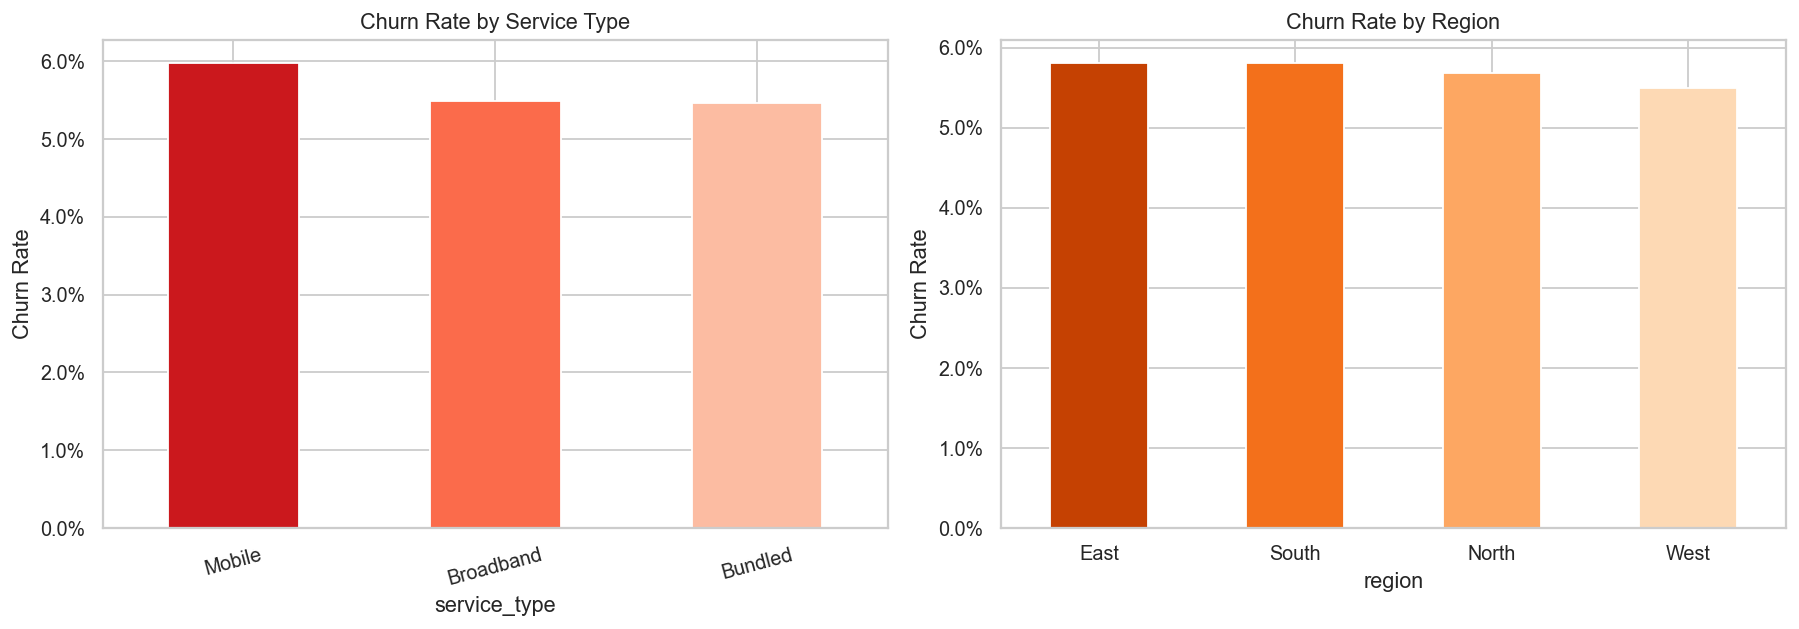

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
svc_churn.plot(kind="bar", ax=axes[0],
               color=sns.color_palette("Reds_r", len(svc_churn)))
axes[0].set_title("Churn Rate by Service Type")
axes[0].set_ylabel("Churn Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].tick_params(axis="x", rotation=15)
reg_churn.plot(kind="bar", ax=axes[1],
               color=sns.color_palette("Oranges_r", len(reg_churn)))
axes[1].set_title("Churn Rate by Region")
axes[1].set_ylabel("Churn Rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("q2_churn_service_region.png")
plt.show()

In [45]:
#  Q3. Contract type vs churn — Two-proportion z-test

In [46]:
mtm   = df[df["contract_type"] == "Month-to-month"]["churn_bool"]
longterm = df[df["contract_type"].isin(["One year", "Two year"])]["churn_bool"]

In [47]:
count  = np.array([mtm.sum(),      longterm.sum()])
nobs   = np.array([len(mtm),       len(longterm)])
z_stat, p_z = proportions_ztest(count, nobs)
sig3 = "Significant" if p_z < 0.05 else "Not significant"

In [48]:
print(f"\nQ3 -- Contract Type vs Churn (Two-proportion z-test):")
print(f"  Month-to-month churn : {mtm.mean():.2%}  (n={len(mtm)})")
print(f"  Long-term churn      : {longterm.mean():.2%}  (n={len(longterm)})")
print(f"  z={z_stat:.3f}, p={p_z:.4f} -> {sig3}")


Q3 -- Contract Type vs Churn (Two-proportion z-test):
  Month-to-month churn : 8.17%  (n=6195)
  Long-term churn      : 2.53%  (n=4825)
  z=12.670, p=0.0000 -> Significant


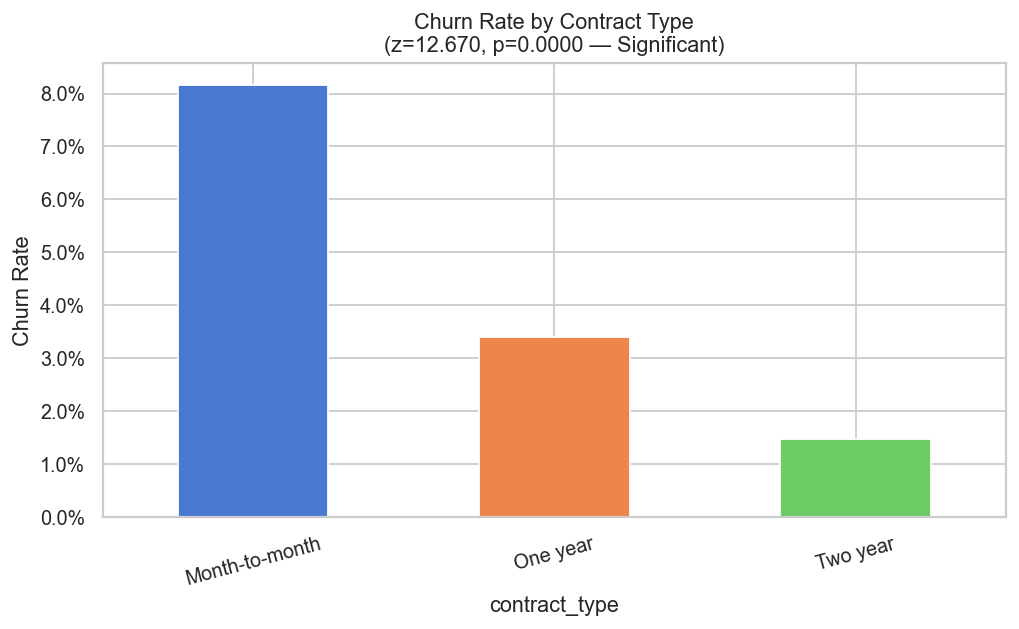

In [49]:
contract_churn = (df.groupby("contract_type")["churn_bool"].mean()
                    .reindex(["Month-to-month", "One year", "Two year"]))
fig, ax = plt.subplots(figsize=(8, 5))
contract_churn.plot(kind="bar", ax=ax,
                    color=sns.color_palette("muted", 3))
ax.set_title(f"Churn Rate by Contract Type\n(z={z_stat:.3f}, p={p_z:.4f} — {sig3})")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("q3_contract_churn.png")
plt.show()

In [50]:
# Q4. Average tenure by region — One-way ANOVA + Tukey HSD

In [59]:
reg_groups = [grp["tenure_months"].dropna().values
              for _, grp in df.groupby("region")]
f_stat, p_anova = f_oneway(*reg_groups)
sig4 = "Significant" if p_anova < 0.05 else "Not significant"

In [60]:
print(f"\nQ4 -- Region vs Tenure ANOVA:")
print(f"  F={f_stat:.3f}, p={p_anova:.4f} -> {sig4}")


Q4 -- Region vs Tenure ANOVA:
  F=1.103, p=0.3466 -> Not significant


In [61]:
tukey4 = pairwise_tukeyhsd(df["tenure_months"], df["region"], alpha=0.05)
print(tukey4.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  East  North  -0.0691 0.9732 -0.4816 0.3433  False
  East  South  -0.0505 0.9889 -0.4587 0.3577  False
  East   West  -0.2706 0.3295 -0.6821  0.141  False
 North  South   0.0187 0.9994 -0.3913 0.4286  False
 North   West  -0.2014 0.5936 -0.6147 0.2119  False
 South   West  -0.2201 0.5105 -0.6291  0.189  False
---------------------------------------------------


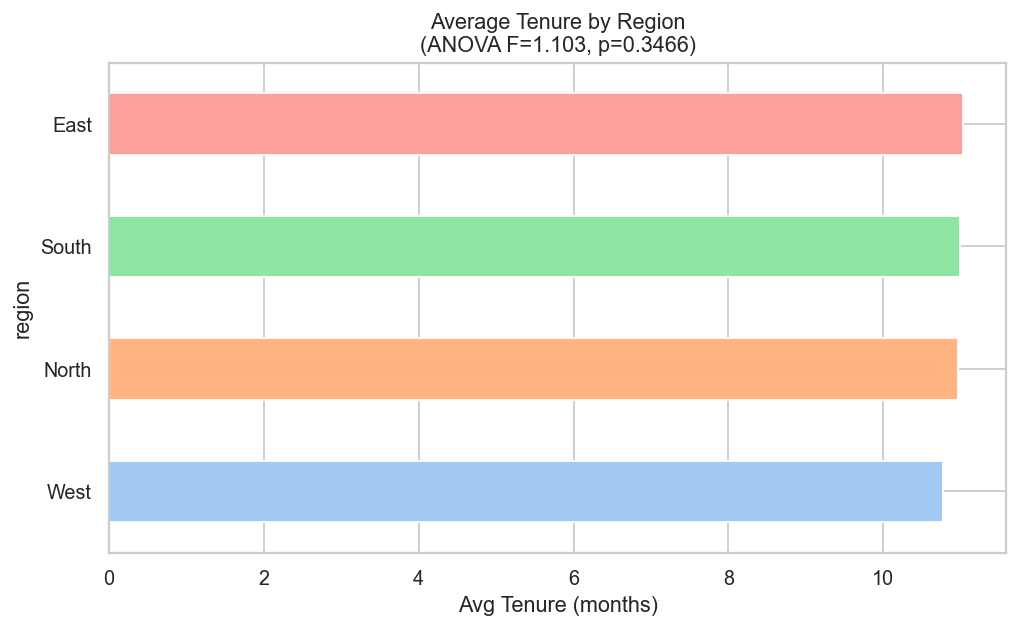

In [62]:
fig, ax = plt.subplots(figsize=(8, 5))
(df.groupby("region")["tenure_months"].mean()
   .sort_values()
   .plot(kind="barh", ax=ax, color=sns.color_palette("pastel", 4)))
ax.set_title(f"Average Tenure by Region\n(ANOVA F={f_stat:.3f}, p={p_anova:.4f})")
ax.set_xlabel("Avg Tenure (months)")
plt.tight_layout()
plt.savefig("q4_region_tenure_anova.png")
plt.show()

In [63]:
# Q5. Contract type vs churn — Chi-square test of independence

In [66]:
ct5 = pd.crosstab(df["contract_type"], df["churn_bool"])
chi2_val, p_chi, dof, _ = chi2_contingency(ct5)
sig5 = "Significant" if p_chi < 0.05 else "Not significant"

print(f"\nQ5 -- Chi-square (Contract Type vs Churn):")
print(f"  chi2={chi2_val:.3f}, dof={dof}, p={p_chi:.4f} -> {sig5}")
print(ct5)


Q5 -- Chi-square (Contract Type vs Churn):
  chi2=168.825, dof=2, p=0.0000 -> Significant
churn_bool      False  True 
contract_type               
Month-to-month   5689    506
One year         2556     90
Two year         2147     32


In [68]:
# Q6. Support calls vs satisfaction & churn

In [74]:
r_sat, p_sat = spearmanr(df["support_calls"], df["satisfaction_score"])
r_churn, p_churn = spearmanr(df["support_calls"], df["churn_bool"].astype(int))

In [75]:
print(f"\nQ6 -- Support Calls vs Satisfaction (Spearman):")
print(f"  r={r_sat:.4f}, p={p_sat:.4f}")
print(f"Q6 -- Support Calls vs Churn (Spearman):")
print(f"  r={r_churn:.4f}, p={p_churn:.4f}")



Q6 -- Support Calls vs Satisfaction (Spearman):
  r=-0.3683, p=0.0000
Q6 -- Support Calls vs Churn (Spearman):
  r=0.1252, p=0.0000


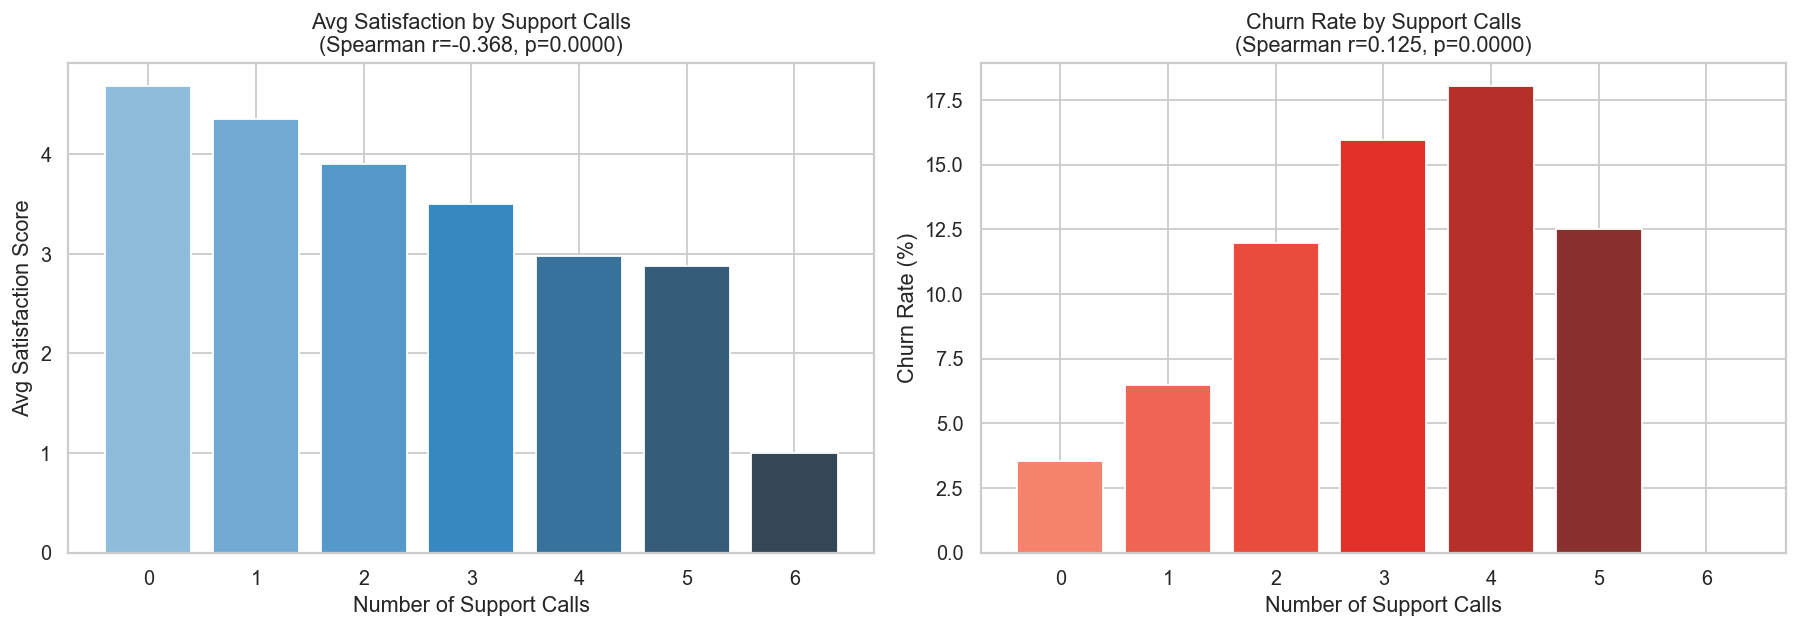

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
avg_sat = df.groupby("support_calls")["satisfaction_score"].mean()
axes[0].bar(avg_sat.index, avg_sat.values,
            color=sns.color_palette("Blues_d", len(avg_sat)))
axes[0].set_title(f"Avg Satisfaction by Support Calls\n(Spearman r={r_sat:.3f}, p={p_sat:.4f})")
axes[0].set_xlabel("Number of Support Calls")
axes[0].set_ylabel("Avg Satisfaction Score")

avg_churn_calls = df.groupby("support_calls")["churn_bool"].mean()
axes[1].bar(avg_churn_calls.index, avg_churn_calls.values * 100,
            color=sns.color_palette("Reds_d", len(avg_churn_calls)))
axes[1].set_title(f"Churn Rate by Support Calls\n(Spearman r={r_churn:.3f}, p={p_churn:.4f})")
axes[1].set_xlabel("Number of Support Calls")
axes[1].set_ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("q6_support_calls_analysis.png")
plt.show()

In [77]:
# Q7. Customer segments most at risk — age group & tenure band

In [78]:
age_churn    = (df.groupby("age_group",    observed=True)["churn_bool"].mean()
                  .sort_values(ascending=False))
tenure_churn = (df.groupby("tenure_band",  observed=True)["churn_bool"].mean()
                  .sort_values(ascending=False))

In [81]:
print("\nQ7 -- Churn Rate by Age Group:")
for k, v in age_churn.items():
    print(f"  {k}: {v:.2%}")
print("\nQ7 -- Churn Rate by Tenure Band:")
for k, v in tenure_churn.items():
    print(f"  {k}: {v:.2%}")


Q7 -- Churn Rate by Age Group:
  36-45: 5.96%
  18-25: 5.93%
  26-35: 5.78%
  56-65: 5.31%
  46-55: 5.08%
  66+: 4.72%

Q7 -- Churn Rate by Tenure Band:
  19-24m: 7.33%
  0-3m: 6.00%
  13-18m: 5.81%
  7-12m: 5.17%
  4-6m: 4.87%


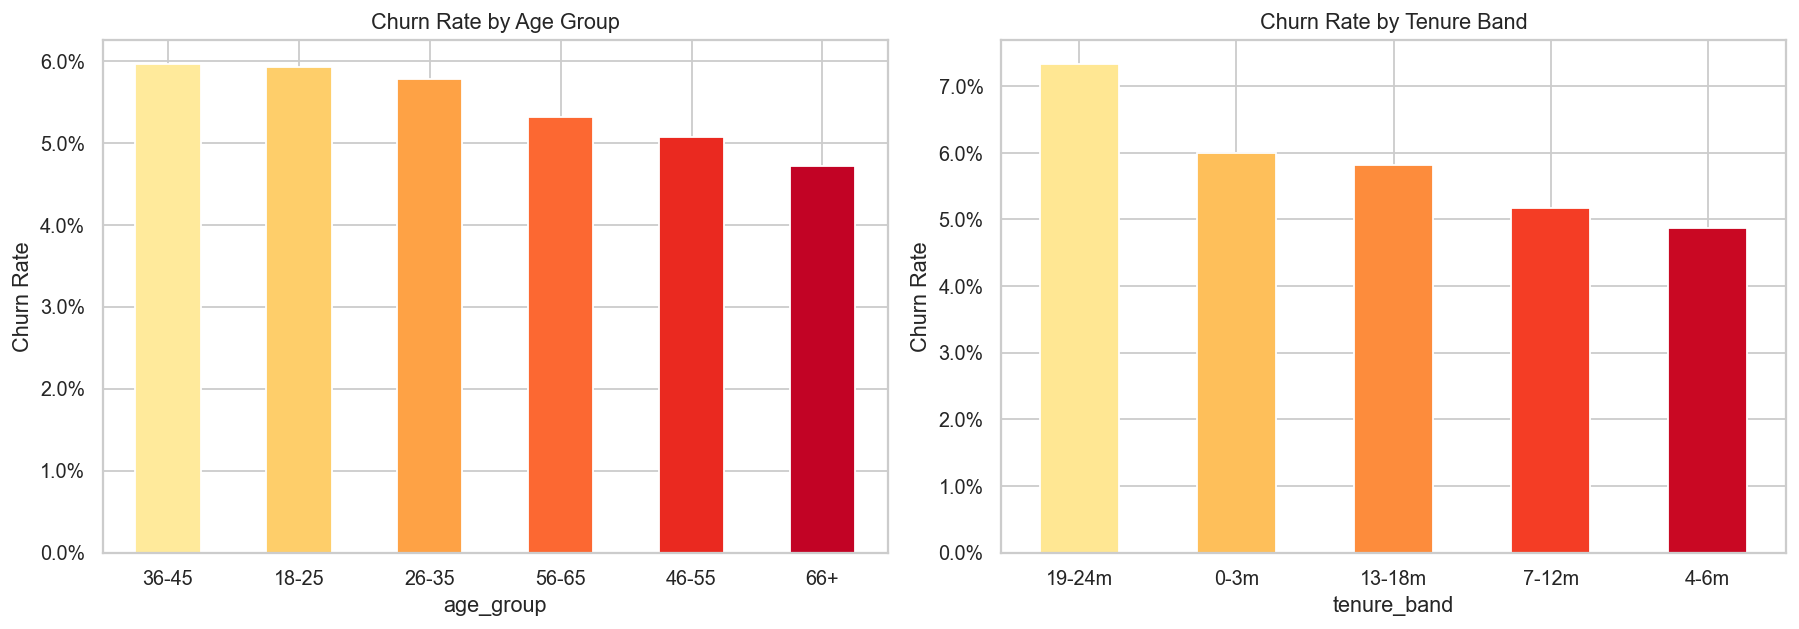

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
age_churn.plot(kind="bar", ax=axes[0],
               color=sns.color_palette("YlOrRd", len(age_churn)))
axes[0].set_title("Churn Rate by Age Group")
axes[0].set_ylabel("Churn Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].tick_params(axis="x", rotation=0)
tenure_churn.plot(kind="bar", ax=axes[1],
                  color=sns.color_palette("YlOrRd", len(tenure_churn)))
axes[1].set_title("Churn Rate by Tenure Band")
axes[1].set_ylabel("Churn Rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("q7_segment_churn_risk.png")
plt.show()

In [85]:
# Q8. Service type vs support complaints & churn link

In [86]:
svc_calls = (df.groupby("service_type")["support_calls"].mean()
               .sort_values(ascending=False))
svc_churn2 = df.groupby("service_type")["churn_bool"].mean()

In [88]:
print("\nQ8 -- Avg Support Calls by Service Type:")
for k, v in svc_calls.items():
    print(f"  {k}: {v:.2f}")


Q8 -- Avg Support Calls by Service Type:
  Mobile: 0.62
  Broadband: 0.62
  Bundled: 0.59


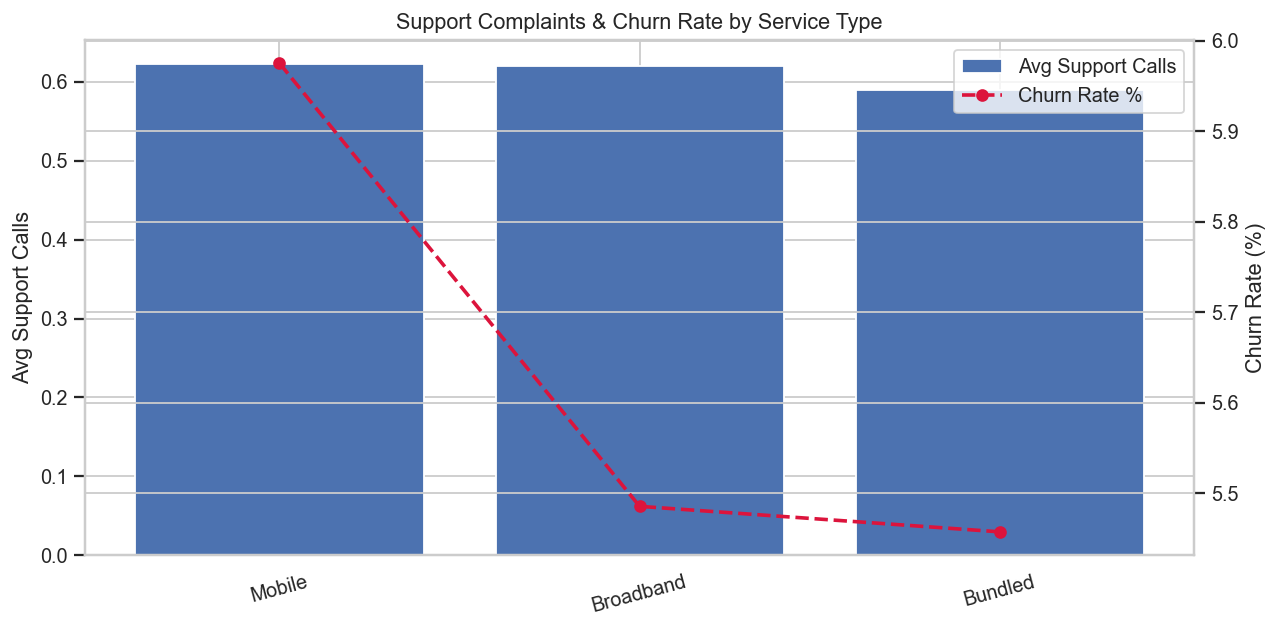

In [92]:
fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(svc_calls))
ax1.bar(x, svc_calls.values, color="#4C72B0", label="Avg Support Calls")
ax2 = ax1.twinx()
ax2.plot(x, svc_churn2.reindex(svc_calls.index).values * 100,
         "o--", color="crimson", linewidth=2, label="Churn Rate %")
ax1.set_xticks(x)
ax1.set_xticklabels(svc_calls.index, rotation=15)
ax1.set_ylabel("Avg Support Calls")
ax2.set_ylabel("Churn Rate (%)")
ax1.set_title("Support Complaints & Churn Rate by Service Type")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig("q8_service_complaints_churn.png")
plt.show()

In [93]:
 # Q9. Monthly charges vs churn — t-test + logistic regression proxy

In [94]:
churned_charges     = df[df["churn_bool"]]["monthly_charges"].dropna()
not_churned_charges = df[~df["churn_bool"]]["monthly_charges"].dropna()

In [96]:
t_stat9, p_t9 = ttest_ind(churned_charges, not_churned_charges, equal_var=False)
sig9 = "Significant" if p_t9 < 0.05 else "Not significant"

In [97]:
print(f"\nQ9 -- Monthly Charges vs Churn (Welch t-test):")
print(f"  Churned mean     : Rs {churned_charges.mean():,.2f}  (n={len(churned_charges)})")
print(f"  Not churned mean : Rs {not_churned_charges.mean():,.2f}  (n={len(not_churned_charges)})")
print(f"  t={t_stat9:.3f}, p={p_t9:.4f} -> {sig9}")


Q9 -- Monthly Charges vs Churn (Welch t-test):
  Churned mean     : Rs 704.35  (n=628)
  Not churned mean : Rs 716.99  (n=10392)
  t=-0.936, p=0.3497 -> Not significant


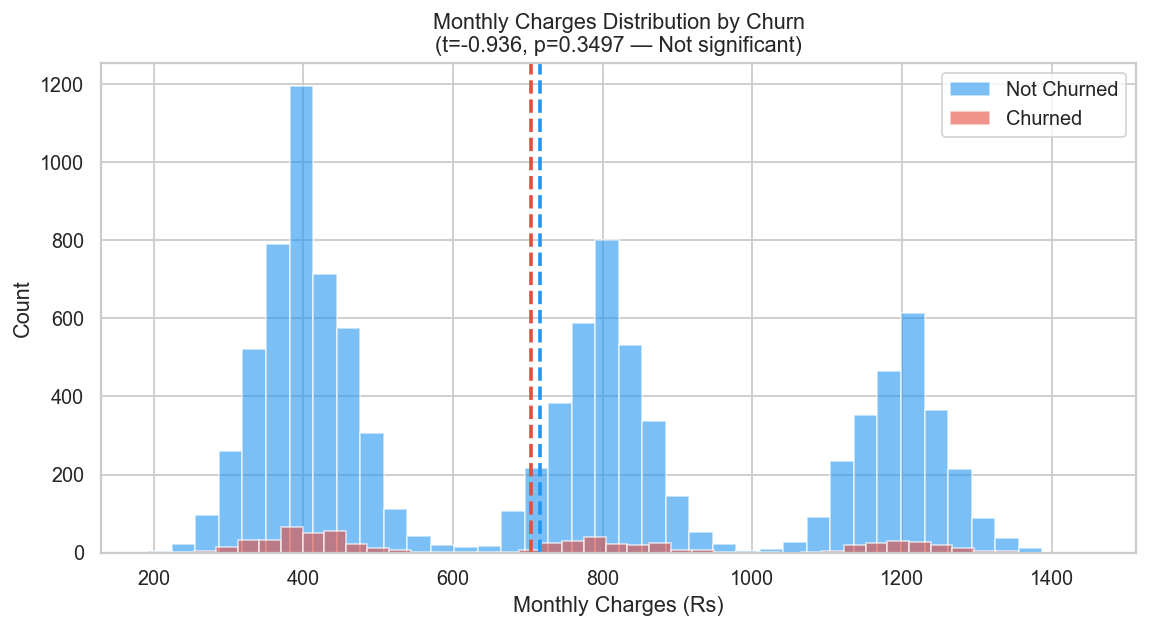

In [99]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(not_churned_charges, bins=40, alpha=0.6, label="Not Churned", color="#2196F3")
ax.hist(churned_charges,     bins=40, alpha=0.6, label="Churned",     color="#e74c3c")
ax.axvline(not_churned_charges.mean(), color="#2196F3", linestyle="--", linewidth=2)
ax.axvline(churned_charges.mean(),     color="#e74c3c", linestyle="--", linewidth=2)
ax.set_title(f"Monthly Charges Distribution by Churn\n(t={t_stat9:.3f}, p={p_t9:.4f} — {sig9})")
ax.set_xlabel("Monthly Charges (Rs)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("q9_charges_churn.png")
plt.show()

In [103]:
# Q10. Actionable recommendations summary (printed)

In [105]:
top_risk_age    = age_churn.idxmax()
top_risk_tenure = tenure_churn.idxmax()
top_risk_svc    = svc_churn.idxmax()
top_risk_reg    = reg_churn.idxmax()